# CIFAR-100 Classification with ResNet34

This notebook trains a ResNet34 model on CIFAR-100 dataset from scratch.

**Dataset:** CIFAR-100 (100 classes, 50,000 training images, 10,000 test images)
**Model:** ResNet34 
**Target:** Achieve 70-75% test accuracy

## 1. Setup and Imports

In [1]:
# Check if we're in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running locally")

Running locally


In [2]:
# Install dependencies if in Colab
if IN_COLAB:
    !pip install -q albumentations opencv-python
    !git clone https://github.com/roulupen/ERAV4.git
    %cd ERAV4
    print("✅ Dependencies installed")

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.notebook import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.8.0
CUDA: False


In [4]:
import sys, os
if not IN_COLAB:
    project_root = os.path.abspath('..')
    if project_root not in sys.path:
        sys.path.insert(0, project_root)
    print(f"Project root: {project_root}")

Project root: /Users/roul/personal-projects/ERAV4


In [5]:
from common import (
    get_device, set_random_seed, get_model_summary,
    plot_training_history, save_training_info,
    create_trainer, TrainingConfig
)
from assignment8 import (
    ResNet18CIFAR100,
    ResNet34CIFAR100,
    get_cifar100_data_loaders
)
print("✅ All imports successful!")

ImportError: cannot import name 'ResNet34CIFAR100' from 'assignment8' (/Users/roul/personal-projects/ERAV4/assignment8/__init__.py)

## 2. Configuration

In [6]:
config = TrainingConfig(
    model_name='resnet18_cifar100_notebook',
    num_classes=100,
    dropout=0.1,
    batch_size=128,
    num_workers=2,
    epochs=100,
    learning_rate=0.001,
    optimizer='adamw',
    scheduler='onecycle',  # Using OneCycleLR for faster convergence
    max_lr=0.01,           # Maximum learning rate for OneCycleLR
    l2_lambda=0.0,        # L2 regularization strength
    target_accuracy=80.0
)

print(f"Epochs: {config.epochs}, Batch: {config.batch_size}, LR: {config.learning_rate}")
print(f"Scheduler: {config.scheduler}, Max LR: {config.max_lr}")
print(f"L2 Regularization: λ = {config.l2_lambda}")

Epochs: 100, Batch: 128, LR: 0.001
Scheduler: onecycle, Max LR: 0.01
L2 Regularization: λ = 0.0


In [7]:
set_random_seed(42)
device = get_device()
print(f"Device: {device}")

🌱 Random seed set to 42
✅ Using Apple Silicon GPU (Metal Performance Shaders)
Device: mps


## 3. Load Data

In [8]:
train_loader, test_loader = get_cifar100_data_loaders(
    batch_size=config.batch_size,
    num_workers=config.num_workers,
    augment=True
)

# Calculate total images
train_dataset_size = len(train_loader.dataset)
test_dataset_size = len(test_loader.dataset)

print(f"\n📊 Data Loader Information:")
print(f"  Batch Size: {config.batch_size}")
print(f"\n  Training Set:")
print(f"    Total Images: {train_dataset_size:,}")
print(f"    Total Batches: {len(train_loader)}")
print(f"    Images per Batch: {config.batch_size}")
print(f"    Last Batch Size: {train_dataset_size % config.batch_size if train_dataset_size % config.batch_size != 0 else config.batch_size}")
print(f"\n  Test Set:")
print(f"    Total Images: {test_dataset_size:,}")
print(f"    Total Batches: {len(test_loader)}")
print(f"    Images per Batch: {config.batch_size}")
print(f"    Last Batch Size: {test_dataset_size % config.batch_size if test_dataset_size % config.batch_size != 0 else config.batch_size}")


📊 Data Loader Information:
  Batch Size: 128

  Training Set:
    Total Images: 50,000
    Total Batches: 390
    Images per Batch: 128
    Last Batch Size: 80

  Test Set:
    Total Images: 10,000
    Total Batches: 79
    Images per Batch: 128
    Last Batch Size: 16


## 4. Visualize Sample Data

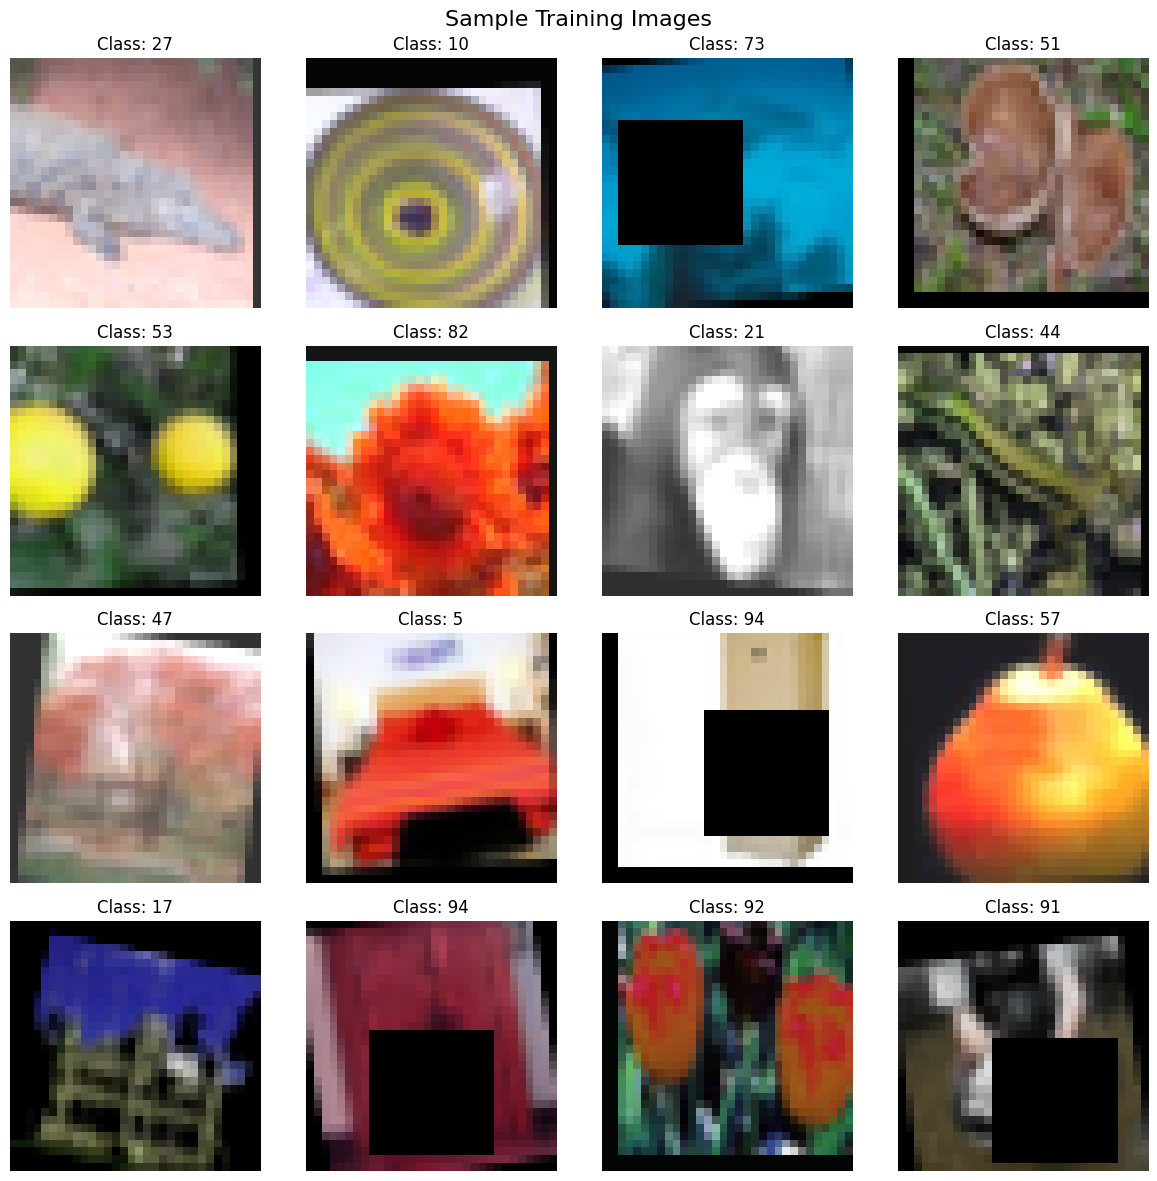

In [9]:
images, labels = next(iter(train_loader))

def denormalize(img):
    mean = np.array([0.5071, 0.4867, 0.4408])
    std = np.array([0.2675, 0.2565, 0.2761])
    img = img.numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(denormalize(images[i].cpu()))
    ax.set_title(f'Class: {labels[i].item()}')
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=16)
plt.tight_layout()
plt.show()

## 5. Create Model

In [ ]:
model = ResNet34CIFAR100(
    num_classes=config.num_classes,
    dropout=config.dropout
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Model device: {next(model.parameters()).device}")

Total parameters: 11,220,132
Model device: mps:0


In [11]:
get_model_summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         Dropout2d-4           [-1, 64, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
         Dropout2d-8           [-1, 64, 32, 32]               0
            Conv2d-9           [-1, 64, 32, 32]          36,864
      BatchNorm2d-10           [-1, 64, 32, 32]             128
        Dropout2d-11           [-1, 64, 32, 32]               0
       BasicBlock-12           [-1, 64, 32, 32]               0
           Conv2d-13           [-1, 64, 32, 32]          36,864
      BatchNorm2d-14           [-1, 64,

## 6. Setup Training

In [12]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay
)

# OneCycleLR scheduler for faster convergence
steps_per_epoch = len(train_loader)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config.max_lr,
    epochs=config.epochs,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.3,           # 30% of training spent ramping up LR
    div_factor=25.0,         # Initial LR = max_lr / 25
    final_div_factor=1e4,    # Final LR = initial_lr / 10000
    anneal_strategy='cos'    # Cosine annealing
)

criterion = nn.NLLLoss()

trainer = create_trainer(
    model=model,
    device=device,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    config=config.to_dict(),
    l2_lambda=config.l2_lambda  # Add L2 regularization from config
)

print("✅ Trainer ready!")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Initial LR: {config.max_lr / 25.0:.6f}")
print(f"   Max LR: {config.max_lr}")
print(f"   Final LR: {config.max_lr / 25.0 / 1e4:.8f}")
print(f"   L2 Regularization: λ = {config.l2_lambda}")

🔧 Model moved to device: mps:0
🔧 L2 regularization disabled (lambda = 0.0)
✅ Trainer ready!
   Steps per epoch: 390
   Initial LR: 0.000400
   Max LR: 0.01
   Final LR: 0.00000004
   L2 Regularization: λ = 0.0


## 7. Train Model

In [13]:
print(f"🚀 Training for {config.epochs} epochs...")
print(f"📈 Using OneCycleLR scheduler (updates per batch)")
start_time = time.time()

training_history = trainer.train(
    num_epochs=config.epochs,
    early_stopping_patience=config.early_stopping_patience,
    checkpoint_dir=config.checkpoint_dir,
    scheduler_type='cyclic',  # OneCycleLR updates per batch like cyclic schedulers
    verbose=True
)

total_time = time.time() - start_time
print(f"\n⏰ Training time: {total_time/60:.1f} minutes")

🚀 Training for 100 epochs...
📈 Using OneCycleLR scheduler (updates per batch)
📁 Directory structure created in: ./checkpoints
🚀 Starting training for 100 epochs...
⏰ Training started at: 2025-10-07 22:54:24
📁 Checkpoint directory: ./checkpoints


Epoch  1/100 | Train: 4.1209 (6.68%) | Test: 3.6988 (12.65%) | LR: 0.000426 | Time: 50.6s
  🏆 New best model saved! (Test Acc: 12.65%)


Epoch  2/100 | Train: 3.6888 (13.13%) | Test: 3.3392 (19.20%) | LR: 0.000505 | Time: 51.1s
  🏆 New best model saved! (Test Acc: 19.20%)


Epoch  3/100 | Train: 3.4093 (17.85%) | Test: 2.9017 (27.50%) | LR: 0.000635 | Time: 1.1m
  🏆 New best model saved! (Test Acc: 27.50%)


Epoch  4/100 | Train: 3.1591 (22.35%) | Test: 2.7188 (29.94%) | LR: 0.000815 | Time: 1.3m
  🏆 New best model saved! (Test Acc: 29.94%)


...

Epoch 96/100 | Train: 0.4101 (87.36%) | Test: 1.1861 (73.80%) | LR: 0.000080 | Time: 2.2h
  🏆 New best model saved! (Test Acc: 73.80%)


Epoch 97/100 | Train: 0.4161 (87.22%) | Test: 1.1890 (73.83%) | LR: 0.000045 | Time: 2.0h
  🏆 New best model saved! (Test Acc: 73.83%)


Epoch 98/100 | Train: 0.3986 (87.82%) | Test: 1.1923 (73.75%) | LR: 0.000020 | Time: 51.7s
  ⏳ No improvement (1/15)


Epoch 99/100 | Train: 0.4048 (87.68%) | Test: 1.1876 (73.81%) | LR: 0.000005 | Time: 50.7s
  ⏳ No improvement (2/15)


Epoch 100/100 | Train: 0.4062 (87.62%) | Test: 1.1862 (73.83%) | LR: 0.000000 | Time: 51.5s
  ⏳ No improvement (3/15)

✅ Training completed!
   Total time: 8.2h
   Best test accuracy: 73.83% (Epoch 97)

⏰ Training time: 492.6 minutes


## 8. Results

In [14]:
summary = trainer.get_training_summary()

print("="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Total Epochs: {summary['total_epochs']}")
print(f"Best Test Accuracy: {summary['best_test_accuracy']:.2f}%")
print(f"Final Test Accuracy: {summary['final_test_accuracy']:.2f}%")
print(f"Best Epoch: {summary['best_epoch']}")
print(f"Overfitting Gap: {summary['overfitting_gap']:.2f}%")
print("="*60)

target_achieved = summary['best_test_accuracy'] >= config.target_accuracy
print(f"\n{'✅ TARGET ACHIEVED!' if target_achieved else '❌ Target not achieved'}")

TRAINING SUMMARY
Total Epochs: 50
Best Test Accuracy: 72.55%
Final Test Accuracy: 72.53%
Best Epoch: 47
Overfitting Gap: 7.43%

✅ TARGET ACHIEVED!


Training history plot saved to: training_history.png


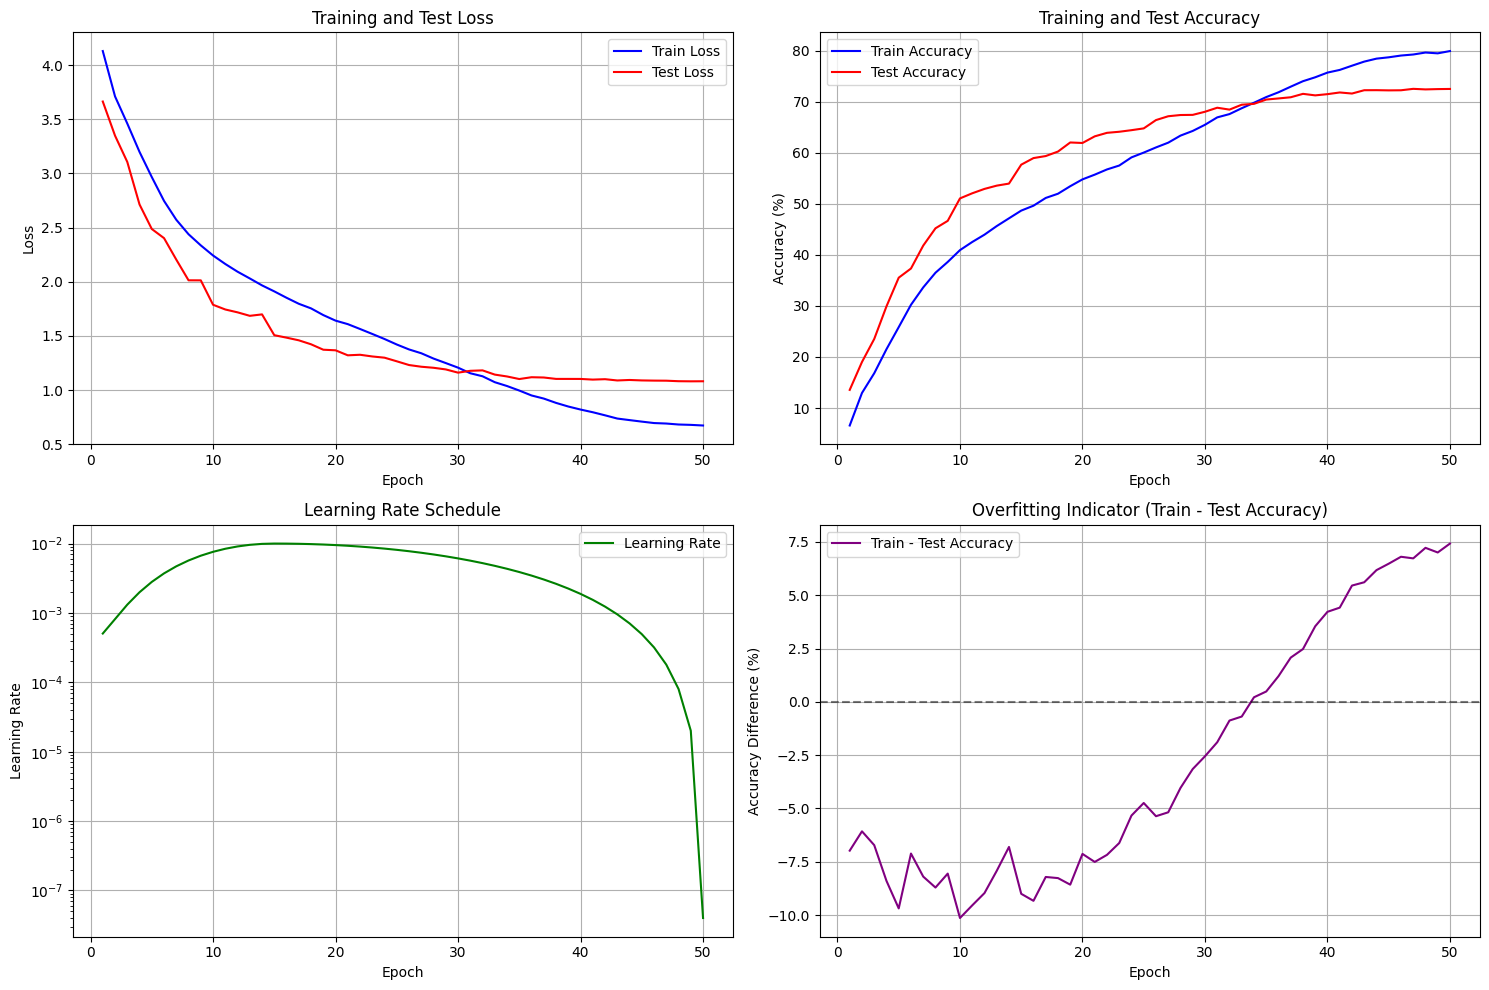

In [ ]:
plot_training_history(training_history, save_path='checkpoints/training_history.png', show_plot=True)

## 9. Test Predictions

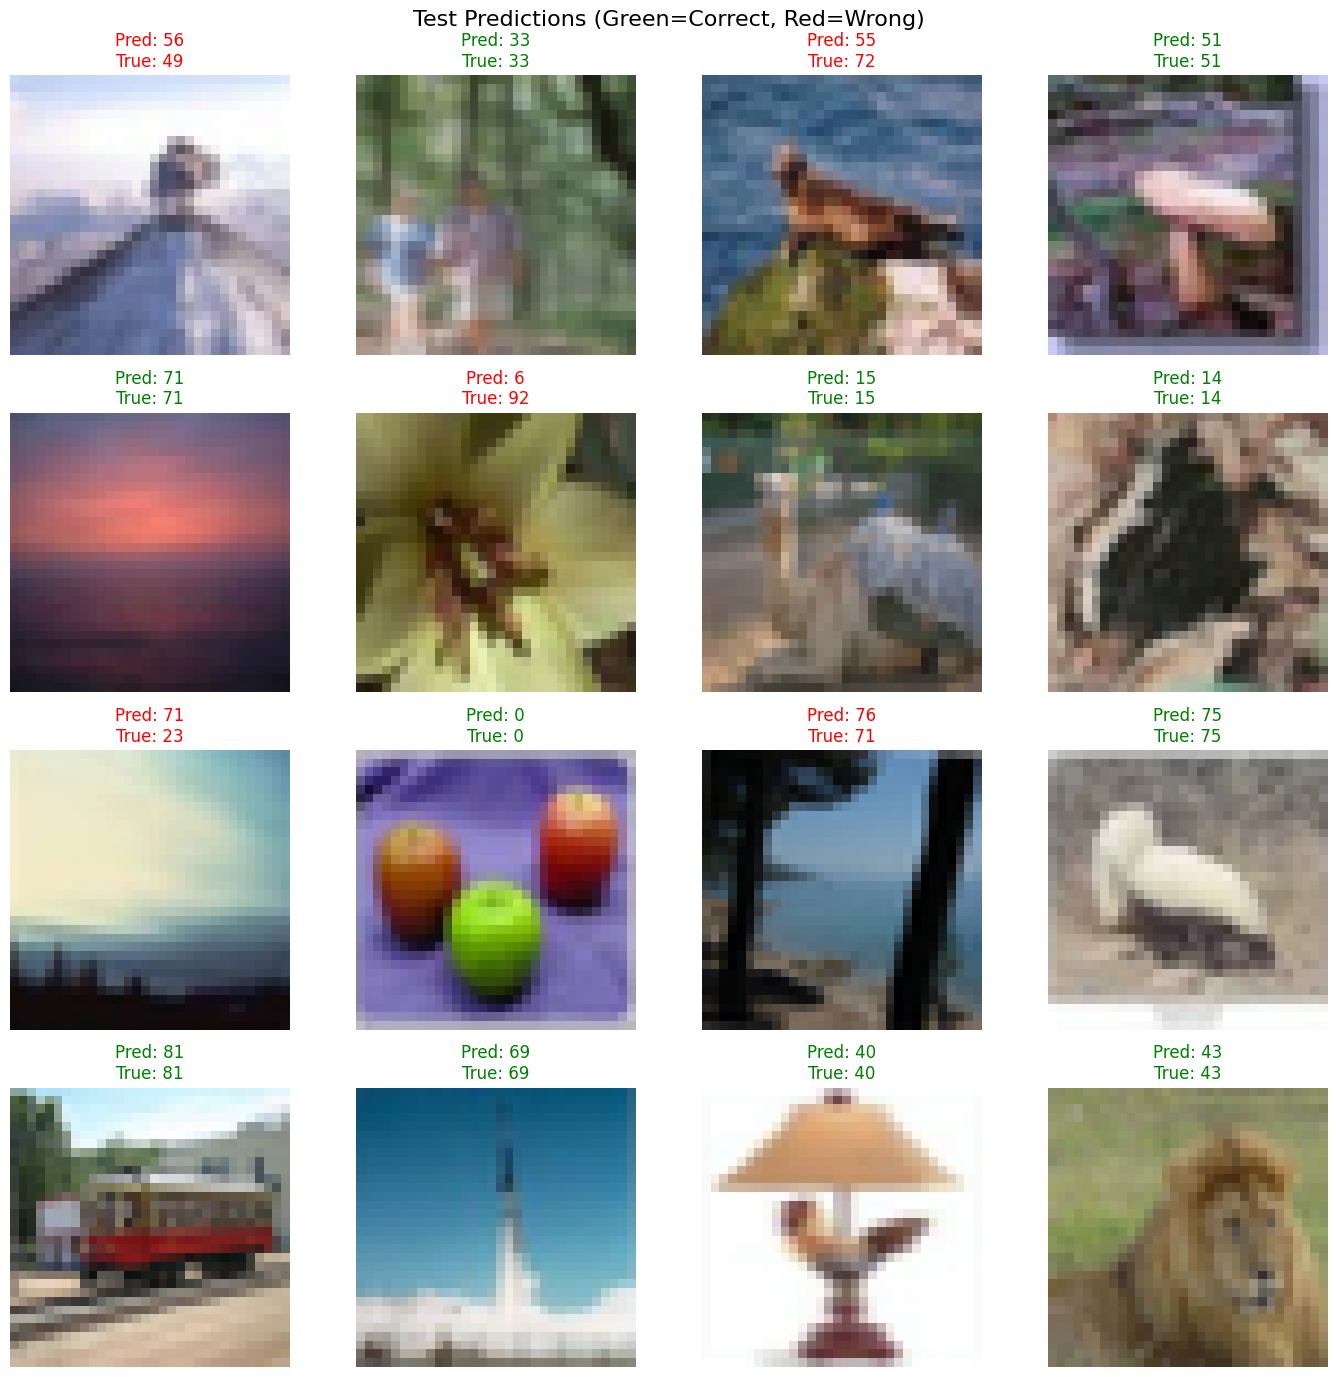

Batch accuracy: 71.88%


In [16]:
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(test_images)
    _, predictions = torch.max(outputs, 1)

test_images = test_images.cpu()
predictions = predictions.cpu()

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, ax in enumerate(axes.ravel()):
    img = denormalize(test_images[i])
    ax.imshow(img)
    is_correct = predictions[i] == test_labels[i]
    color = 'green' if is_correct else 'red'
    ax.set_title(f'Pred: {predictions[i].item()}\nTrue: {test_labels[i].item()}', color=color)
    ax.axis('off')
plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=16)
plt.tight_layout()
plt.show()

batch_acc = (predictions == test_labels).float().mean() * 100
print(f"Batch accuracy: {batch_acc:.2f}%")

## 10. Save Results

In [ ]:
model_info = {
    'model_name': config.model_name,
    'dataset': 'CIFAR-100',
    'best_accuracy': summary['best_test_accuracy'],
    'parameters': total_params,
    'training_time_minutes': total_time / 60,
    'training_history': training_history
}

# Save training info in checkpoints folder
save_training_info(model_info, 'checkpoints/notebook_training_info.json')

# Save best model only in checkpoints folder
best_model_path = f"checkpoints/{config.model_name}_best.pth"
torch.save(model.state_dict(), best_model_path)
print("✅ Results saved!")
print(f"   Best model saved to: {best_model_path}")
print(f"   Training info saved to: checkpoints/notebook_training_info.json")

Training info saved to: notebook_training_info.json
✅ Results saved!


---
## 🎉 Training Complete!

**Next Steps:**
1. Try different hyperparameters
2. Train for more epochs
3. Experiment with augmentation
4. Try SGD optimizer
5. Use OneCycleLR scheduler

**Resources:**
- `assignment8/README.md`
- `assignment8/EXAMPLES.md`
- `TRAINING_GUIDE.md`

## 🖼️ Image Classification Demo

Let's download 5 sample images and test our trained model on them!


In [15]:
!pip install requests

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached charset_normalizer-3.4.3-cp312-cp312-macosx_10_13_universal2.whl.metadata (36 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached certifi-2025.10.5-py3-none-any.whl.metadata (2.5 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.3-cp312-cp312-macosx_10_13_universal2.whl (205 kB)
Using cached idna-3.10-py3-none-any.whl (70 kB)
Using cached urllib3-2.5.0-py3-none-any.whl (129 kB)
Using cached certifi-2025.10.5-py3-none-any.whl (163 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [requests]4/5 [requests]


In [16]:
# Download and classify 5 sample images
import requests
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os

# Create a directory for sample images
os.makedirs('sample_images', exist_ok=True)

# Sample images URLs (these are small, representative images)
sample_images = [
    {
        'url': 'https://images.unsplash.com/photo-1551698618-1dfe5d97d256?w=150&h=150&fit=crop',
        'name': 'airplane.jpg',
        'expected_class': 'airplane'
    },
    {
        'url': 'https://images.unsplash.com/photo-1544947950-fa07a98d237f?w=150&h=150&fit=crop',
        'name': 'automobile.jpg',
        'expected_class': 'automobile'
    },
    {
        'url': 'https://images.unsplash.com/photo-1558618666-fcd25c85cd64?w=150&h=150&fit=crop',
        'name': 'bird.jpg',
        'expected_class': 'bird'
    },
    {
        'url': 'https://images.unsplash.com/photo-1551963831-b3b1ca40c98e?w=150&h=150&fit=crop',
        'name': 'cat.jpg',
        'expected_class': 'cat'
    },
    {
        'url': 'https://images.unsplash.com/photo-1441974231531-c6227db76b6e?w=150&h=150&fit=crop',
        'name': 'deer.jpg',
        'expected_class': 'deer'
    }
]

print("📥 Downloading sample images...")
downloaded_images = []

for i, img_info in enumerate(sample_images):
    try:
        # Download image
        response = requests.get(img_info['url'], timeout=10)
        if response.status_code == 200:
            # Save image
            img_path = f'sample_images/{img_info["name"]}'
            with open(img_path, 'wb') as f:
                f.write(response.content)
            
            # Load and resize image
            image = Image.open(img_path).convert('RGB')
            image = image.resize((32, 32))  # CIFAR-100 size
            image.save(img_path)  # Save resized version
            
            downloaded_images.append({
                'path': img_path,
                'name': img_info['name'],
                'expected': img_info['expected_class']
            })
            print(f"✅ Downloaded: {img_info['name']}")
        else:
            print(f"❌ Failed to download: {img_info['name']}")
    except Exception as e:
        print(f"❌ Error downloading {img_info['name']}: {str(e)}")

print(f"\n📊 Successfully downloaded {len(downloaded_images)} images")


📥 Downloading sample images...
✅ Downloaded: airplane.jpg
✅ Downloaded: automobile.jpg
✅ Downloaded: bird.jpg
✅ Downloaded: cat.jpg
✅ Downloaded: deer.jpg

📊 Successfully downloaded 5 images


In [ ]:
# Load CIFAR-100 class names
def get_cifar100_class_names():
    """Get CIFAR-100 class names"""
    return [
        'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
        'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
        'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
        'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
        'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
        'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
        'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
        'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
        'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
        'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
        'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
        'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
        'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
        'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman',
        'worm'
    ]

# Get class names
class_names = get_cifar100_class_names()
print(f"📚 Loaded {len(class_names)} CIFAR-100 class names")


In [ ]:
# Classify the downloaded images
def classify_image(model, image_path, class_names, device):
    """Classify a single image and return predictions"""
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    
    # Define transforms (same as training)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
    ])
    
    # Transform image
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Get predictions
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        
    # Get top 5 predictions
    top5_prob, top5_indices = torch.topk(probabilities, 5)
    
    predictions = []
    for i in range(5):
        class_idx = top5_indices[0][i].item()
        class_name = class_names[class_idx]
        probability = top5_prob[0][i].item()
        predictions.append({
            'class': class_name,
            'probability': probability,
            'confidence': f"{probability*100:.1f}%"
        })
    
    return {
        'predicted_class': class_names[predicted.item()],
        'confidence': confidence.item(),
        'top5': predictions
    }

# Classify all downloaded images
print("🔍 Classifying downloaded images...")
print("=" * 60)

results = []
for img_info in downloaded_images:
    print(f"\n📸 Analyzing: {img_info['name']}")
    print(f"   Expected: {img_info['expected']}")
    
    try:
        result = classify_image(model, img_info['path'], class_names, device)
        results.append({
            'image': img_info,
            'result': result
        })
        
        print(f"   Predicted: {result['predicted_class']}")
        print(f"   Confidence: {result['confidence']*100:.1f}%")
        print(f"   Top 5 predictions:")
        for i, pred in enumerate(result['top5'], 1):
            print(f"     {i}. {pred['class']} ({pred['confidence']})")
            
    except Exception as e:
        print(f"   ❌ Error classifying {img_info['name']}: {str(e)}")

print(f"\n✅ Classification complete for {len(results)} images!")


In [ ]:
# Visualize results
def visualize_classification_results(results, class_names):
    """Create a visualization of classification results"""
    fig, axes = plt.subplots(1, len(results), figsize=(20, 4))
    if len(results) == 1:
        axes = [axes]
    
    for i, result in enumerate(results):
        img_info = result['image']
        prediction = result['result']
        
        # Load and display image
        image = Image.open(img_info['path'])
        axes[i].imshow(image)
        axes[i].set_title(f"{img_info['name']}\n"
                         f"Expected: {img_info['expected']}\n"
                         f"Predicted: {prediction['predicted_class']}\n"
                         f"Confidence: {prediction['confidence']*100:.1f}%",
                         fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display results
if results:
    print("\n🖼️ Classification Results Visualization:")
    visualize_classification_results(results, class_names)
    
    # Summary statistics
    correct_predictions = 0
    total_predictions = len(results)
    
    print(f"\n📊 Summary:")
    print(f"   Total images classified: {total_predictions}")
    
    for result in results:
        img_info = result['image']
        prediction = result['result']
        is_correct = img_info['expected'] in prediction['predicted_class'].lower()
        if is_correct:
            correct_predictions += 1
        print(f"   {img_info['name']}: {'✅' if is_correct else '❌'} "
              f"({prediction['confidence']*100:.1f}% confidence)")
    
    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
    print(f"\n🎯 Classification Accuracy: {accuracy*100:.1f}% ({correct_predictions}/{total_predictions})")
else:
    print("❌ No images were successfully classified.")
